# workflow

explore an end-to-end workflow    


resource respitory, book version, etc.

what_were_covering:   
1: "data(prepare to load)      
2: "build model"     
3: "fitting the model to data(training)"    
4: "making predictions and evaluting a model(inference)"   
5: "saving and loading model"   
6: "putting it all together"   


In [272]:
import torch
from torch import nn #nn contains all of PyTorch's building blocks for neural networks
import matplotlib.pyplot as plt

torch.__version__

'2.12.0+cu132'

## 1.Data (preparing and loading)

Data can be anything in machine learing.  
* excel speadsheet
* images
* videos
* Audio
* DNA, Text

Machine learning is 2 parts:     
1. get data into a numerical repretation.
2. build a model to learn patterns in that numerical representation.

To show, create some *known* data using the linear regression formula.（线性回归）   

use a linear regression formula to make a straight line with *known* **parameters**.



In [273]:
# Creating  known parameters(parameters:参数)
#本段意在理解参数对于输入与输出张量变换的联系
weight = 0.7 #在这里相当于Y=ax+b的a
bias = 0.3 #在这里相当于Y=ax+b的b
#weights和bias是两个很重要的概念，weight即权重，指激活值，一般作为系数。bias指偏置值，一般用于校正最终的参数。
#sigmoid是可以归一化weights的，不过这是从3b1b学来的，现在这个教程还没有讲到。


#create some data
start = 0
end = 1
step = 0.02
X = torch.arange(start, end, step).unsqueeze(dim=1) #add an extra dimension, remove to get a 1-layer tensor
Y = weight * X + bias

X[:10], Y[:10], len(X), len(Y)

(tensor([[0.0000],
         [0.0200],
         [0.0400],
         [0.0600],
         [0.0800],
         [0.1000],
         [0.1200],
         [0.1400],
         [0.1600],
         [0.1800]]),
 tensor([[0.3000],
         [0.3140],
         [0.3280],
         [0.3420],
         [0.3560],
         [0.3700],
         [0.3840],
         [0.3980],
         [0.4120],
         [0.4260]]),
 50,
 50)

###  Splitting data into training and test sets(one of most impt concepts in general)

* 3 datasets, just like learning:
* course material = training set
* Practice exam = validation set (tune model patterns)
* Final exam = test set (see if model is ready)

let's create a training and test set with our data
 

In [274]:
#create train/test split

train_split = int(0.8 * len(X))
X_train, Y_train = X[:train_split], Y[:train_split]
X_test, Y_test = X[train_split:], Y[train_split:]

len(X_train), len(Y_train), len(X_test), len(Y_test)
#validation set is unnecessary sometimes


(40, 40, 10, 10)

In [275]:
X_train, Y_train


(tensor([[0.0000],
         [0.0200],
         [0.0400],
         [0.0600],
         [0.0800],
         [0.1000],
         [0.1200],
         [0.1400],
         [0.1600],
         [0.1800],
         [0.2000],
         [0.2200],
         [0.2400],
         [0.2600],
         [0.2800],
         [0.3000],
         [0.3200],
         [0.3400],
         [0.3600],
         [0.3800],
         [0.4000],
         [0.4200],
         [0.4400],
         [0.4600],
         [0.4800],
         [0.5000],
         [0.5200],
         [0.5400],
         [0.5600],
         [0.5800],
         [0.6000],
         [0.6200],
         [0.6400],
         [0.6600],
         [0.6800],
         [0.7000],
         [0.7200],
         [0.7400],
         [0.7600],
         [0.7800]]),
 tensor([[0.3000],
         [0.3140],
         [0.3280],
         [0.3420],
         [0.3560],
         [0.3700],
         [0.3840],
         [0.3980],
         [0.4120],
         [0.4260],
         [0.4400],
         [0.4540],
         [

how we better visualize our data?   
this is where data explorer's motto comes in!  
VISUALIZE


In [276]:
def plot_predictions(train_data = X_train,
                     train_labels = Y_train,
                     test_data = X_test,
                     test_labels = Y_test,
                     predictions = None):
  """
  plots training data, test data and compares predictions.
  """

  plt.figure(figsize=(10,7)) 

  #plot training data in blue
  plt.scatter(train_data, train_labels, c="b", s=4, label = "Training")
  #plot test data in green
  plt.scatter(test_data, test_labels, c="g", s=4, label = "Testing")

  #Are there predictions?
  if predictions is not None:
    #plot the predictions if they exist
    plt.scatter(test_data, predictions, c="r", s=4, label = "Predictions")

  #show legend
  plt.legend(prop={"size":14});


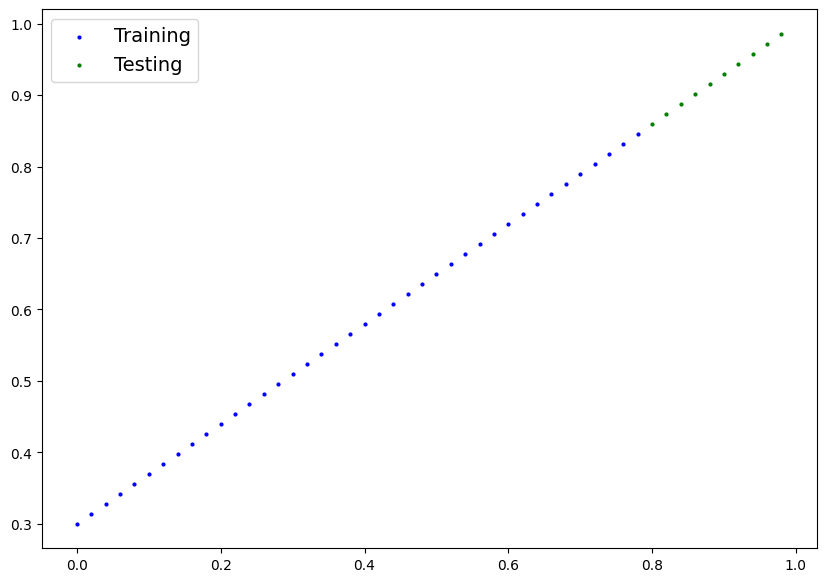

In [277]:
plot_predictions();

## 2.building our first pytorch model

our 1st pytorch model  
better familiar with OOP(面向对象编程)   

what model does:   
* Start with random values(weight,bias)
* look at training data and adjust the random values to better represent (or get closer to) the ideal valves(the weight and bias values we used to create the data)
How does do so?    
1. gradient descent(梯度下降)
2. backpropagation（反向传播）


In [278]:
from torch import nn
# create linear regression model class
class LinearRegressionModel(nn.Module):#nn.Module:almost everything in PyTorch inherhits from nn.Module
    def __init__(self):
        super().__init__()
#初始化参数以进行计算。取决于训练方式的不同，这一节写的也会不同。比如
#本节只定义了weight和bias，其他时候会用其他的语法。

        self.weights = nn.Parameter(torch.randn(1,#从一个随机权重开始，尝试将其调整到理想weight
                                                requires_grad=True,#这个参数可以用梯度下降优化吗？
                                                dtype=torch.float))#Pytorch更倾向使用torch.float32
        self.bias = nn.Parameter(torch.randn(1,#从一个随机偏置开始，尝试将其调整到理想偏置
                                             requires_grad=True,#这个参数可以用梯度下降优化吗？
                                             dtype=torch.float))#Pytorch更倾向使用torch.float32

#Forward method to define the computation in the model（指定了模型的计算方式）
#每一个nn.Module的子类都需要用forward覆写。
    def forward(self, x:torch.Tensor) -> torch.tensor:# x is the imput
        return self.weights * x + self.bias#this is the linear regression formula




这些是3b1b的补充，用以讲清楚何为反向传播和梯度下降。
cost：作为一个“代价”指明了神经网络输出数据的差距与正常数据的差距有多大。网络可以正常分类时这个代价就很小。（还有Loss针对单个数据，但是现在多混用）

cost的值需要结合神经网络的最后一层和目标标记值来得到（有一种专门的计算方式，一般是一个函数）。后一层一般由前一层的值激活值a(L-1) * 权重ω(L) + 偏置值b(L)运算得到的值再给予一个sigmoid以引入非线性得到。前一层的值继续重复，直到最后一层，数据输出层。便是**前向传播**。

优化神经网络的激活值ω和偏置值b即就是优化这个cost的大小。把每一个参数看成是一个未知数（n元n次的元），对此求梯度，这是**反向传播**， 用链式法则从输出层往回算梯度。有了这个梯度，便能通过更改ω和b的方式让cost的值减小。具体表现为 ω(New) = ω(old) - 学习率（学习率是人为调控的数值，衡量一次“改变”多少值，其实就是在细化与效率之间取得平衡） * 梯度（梯度在这里就是衡量哪一个权重下降的更重要一点）。这种特殊的运算方式便叫作**梯度下降**。cost降得越低，一般来说训练的模型准确率越高。

`requires_grad = True` 将通过跟踪这个特定参数的梯度以便与torch.autograd和梯度下降法一起使用（在许多torch.nn modules里，这个是默认设置）

### Pytorch model building essentials

* torch.nn - 包含了所有训练神经网络所需的组件。
* torch.nn.parameter - 模型需要去学习的变量。一般一个来自torch.nn的PyTorch层会设置好这些参数。
* torch.nn.Module - 所有神经网络的基础类。如果你继承它，你应该覆写它。
* torch.optim - 这是PyTorch中优化器所在的地方，它们将帮助进行梯度下降。
* def forward() - 所有 nn.Module 的子类都需要覆写 forward()，这个方法定义了前向计算中会发生什么。
在PyTorch cheatsheet查看更多  https://pytorch-cn.com/tutorials/beginner/ptcheat.html

### checking the contents of our pytorch models

Now we've created a model, let's see what's inside.

we check our model parameters or what's inside using `.parameters()`



In [279]:
#Create a rand seed
torch.manual_seed(42)

#create an instance of the module(this is a subclass of nn.Module)
model_0 = LinearRegressionModel()

#check out parameters
list(model_0.parameters())

#按理来说种子应该是随机的，但是为了演示，我们就用固定的种子吧。

[Parameter containing:
 tensor([0.3367], requires_grad=True),
 Parameter containing:
 tensor([0.1288], requires_grad=True)]

In [280]:
#List named parameters 
model_0.state_dict()

OrderedDict([('weights', tensor([0.3367])), ('bias', tensor([0.1288]))])

现在我们得到了这两个parameters，我们如何把它们变成0.7和0.3呢 (注意，在大部分情况下，我们不知道这些变量要变成几)

In [281]:
weight,bias

(0.7, 0.3)

### Making predictions using `torch.inference_mode()`

To check our model's predictive power, let's see how well it predicts `y_test` based on `x_test`.  

When we pass data from our model, it's going to run it through the `forward()` method.


In [282]:
# Make predictions with model

with torch.inference_mode():
    Y_preds = model_0(X_test)

Y_preds


tensor([[0.3982],
        [0.4049],
        [0.4116],
        [0.4184],
        [0.4251],
        [0.4318],
        [0.4386],
        [0.4453],
        [0.4520],
        [0.4588]])

In [283]:
Y_test


tensor([[0.8600],
        [0.8740],
        [0.8880],
        [0.9020],
        [0.9160],
        [0.9300],
        [0.9440],
        [0.9580],
        [0.9720],
        [0.9860]])

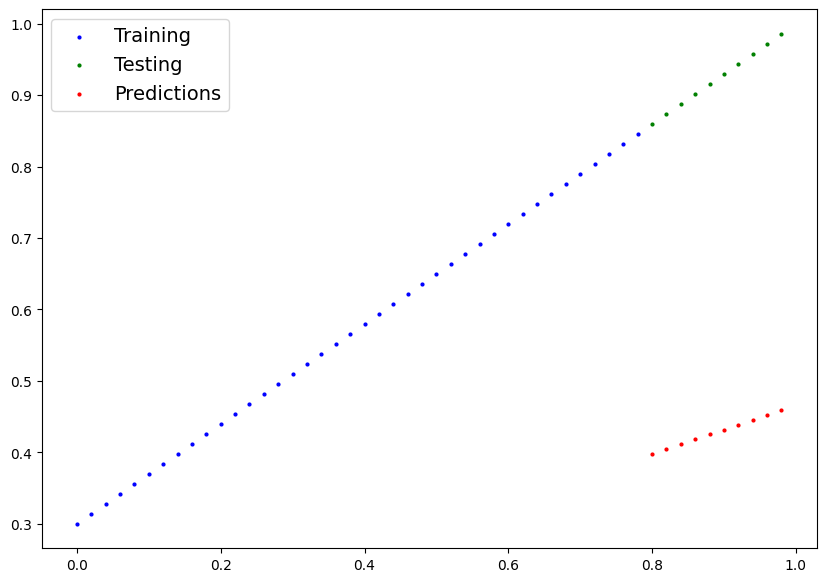

In [284]:
plot_predictions(predictions=Y_preds)
#通过使用随机的参数产生了完全随机的预测过程
#因为我和教程使用了完全相同的种子，所以预测出来的数是一样的。

In [285]:
#这是另一种预测的方法，不过推荐使用第一种
#Y_preds = model_0(X_test)
#Y_preds
#观看输出结果grad_fn=<AddBackward0>可知此时虽然在预测（推理）并非训练但是也在追踪”计算图“。而第一种方法禁用了追踪计算图（因为没有必要）。这样可以省下显存。
#”计算图“是用来在参数迭代时记录迭代方式的。训练时有大用（反向传播算梯度），推理时没用。
#不用torch.no_grad(),已经被淘汰了。但是已有代码很可能有。
#在此不进行更多操作，防止后边变量被覆盖。

## 3.Train model

The whole idea of training is for a model to move some *unknown* parameters(these may be random) to some *known* parameters   
Or in other words from a poor representation of the data to a better representation of the data.   
One way to measure how poor or how wrong your models predictions are is to use a loss(Cost) function. Check out it in 3b1b.  

Another name is criterion.   


Followings are things we need to train.

* **loss function** A function to measure how wrong your model's predictions are to the ideal outputs. lower is better.

* **optimizer:** Takes into account the lose of a model and adjusts the model's parameters(e.g. weights&bias)  
    * inside a optimizer we'll often have to set 2 parameters:
        * `params` - the model parameters you'd like to optimize. for example,`params= model_0,parameters()`
        * `lr`(learning rate) - the learning rate is a hyperparameter that defines how big/small the optimizer changes the parameters with each step.

And specifically for PyTorch, we need:
* A training loop
* A testing loop


In [286]:
#check model's parameters
model_0.parameters(),model_0.state_dict()


(<generator object Module.parameters at 0x000002AAA4D43E60>,
 OrderedDict([('weights', tensor([0.3367])), ('bias', tensor([0.1288]))]))

这次使用L1 loss function为例。衡量的是每个输入元素和输出元素之间的平均绝对误差（MAE）。
https://docs.pytorch.ac.cn/docs/stable/generated/torch.nn.L1Loss.html

https://docs.pytorch.ac.cn/docs/stable/optim.html


In [287]:
#set up a loss function
loss_fn = nn.L1Loss()


#set up a optimizer（SGD,Adam etc are popular. use SGD here)
optimizer = torch.optim.SGD(params=model_0.parameters(),
                            lr = 0.01)#lr = learning rate(前面提到的”学习率“出现了，就是参数一步改变最小多少) = possibly the most impt hyperparameter you can set




选择合适的误差函数和优化器取决于特定的问题。对于回归分析问题，`nn.L1loss()`和`torch.optim.SGD()`好用。但是比如图像处理时，或许可以使用`nn.BCELoss()`(binary cross entropy loss).

### Building a training loop (and a testing loop) in Pytorch

we need in a training loop:
0. Loop through data(遍历数据)(*AI-把数据反复喂给模型，一轮为一个epoch*)
1. Forward pass (前向传播-数据流过模型的forward方法，对数据产生预测结果。)(involves data moving though model's `forward()`) to make predictions on data
2. Calculate the loss (计算损失-将前向传播的预测值于真实值做对比。)(compare forward pass predictions to ground truth labels)
3. Optimizer zero grad(优化器梯度清零-*AI-把上一轮累积的梯度归零以防止梯度累加干扰本轮更新*)
4. Loss backward(**反向传播**-从损失值出发沿着网络反向计算每个参数关于损失函数的梯度) - move backwards through network to caucalate the graditents of each of the parameters of our model with respect the loss func.
5. Optimizer step(**梯度下降**-用优化器根据刚才算出的梯度来调整模型参数以尝试改善损失) - use the optimizer to adjust our model's parameters to try and improve the loss. 

In [ ]:
torch.manual_seed(42)

# An epoch is one loop through the data(this is a hyperparameter(超参数，由人自主设定的调优参数))

epochs = 201

#track different valves
epoch_count = []
loss_valves = []
test_loss_valves = []

### Training
# 0. Loop through the data
# Pass the data through the model for a number of epochs(eg.100)
for epoch in range(epochs):
    #set the model to training code
    model_0.train() #train mode in pytorch sets all parameters that require gradients

    #1.Forward pass on train data using the forward() method inside
    Y_pred = model_0(X_train)   

    #2.calculate the loss 
    loss = loss_fn(Y_pred,Y_train)
    #print(f"loss:{loss}")
    
    #3.optimizer zero grad(they accumulate by default)

    optimizer.zero_grad()

    #4.perform backpropagation on the loss with respect to the parameters of the model(反向计算每个参数关于损失函数的梯度)
    loss.backward()

    #5.step the optimizer(perform gradient decent)
    optimizer.step() 
    # by default how the optimizer change will accumulate through the loop so 
    # we have to zero them above in step 3 for the next iteration of the loop
    #默认情况下，优化器的更改会在循环中累积，所以我们必须在步骤3中将它们归零，以便循环的下一次迭代。

    ###testing
    model_0.eval() #turn off other different settings in the model not needed for evaulation/testing
    with torch.inference_mode():#turns off gradient tracking & a couple more things behind the scenes
        #may see also torch.no_grad() in older Pytorch code
        #1. Do the forward pass
        test_pred = model_0(X_test)

        #2. Calculate the loss
        test_loss = loss_fn(test_pred,Y_test)
        #这是测试集专用的loss

        #调试
    if epoch % 10 == 0:
        epoch_count.append(epoch)
        loss_valves.append(loss)
        test_loss_valves.append(test_loss)
        print(f"Epoch:{epoch} | Loss:{loss} |Test loss:{test_loss}")
#所有这些可以写成一个函数

#检测
#print(f"target Weight:{weight}")
#print(f"target Bias:{bias}")
#print(f"State:{model_0.state_dict()}")

#此处有一个未尽的问题：（train）oss和 test loss的区别是什么
#叫AI遍历时能查到


Epoch:0 | Loss:0.31288138031959534 |Test loss:0.48106518387794495
Epoch:10 | Loss:0.1976713240146637 |Test loss:0.3463551998138428
Epoch:20 | Loss:0.08908725529909134 |Test loss:0.21729660034179688
Epoch:30 | Loss:0.053148526698350906 |Test loss:0.14464017748832703
Epoch:40 | Loss:0.04543796554207802 |Test loss:0.11360953003168106
Epoch:50 | Loss:0.04167863354086876 |Test loss:0.09919948130846024
Epoch:60 | Loss:0.03818932920694351 |Test loss:0.08886633068323135
Epoch:70 | Loss:0.03476089984178543 |Test loss:0.0805937647819519
Epoch:80 | Loss:0.03132382780313492 |Test loss:0.07232122868299484
Epoch:90 | Loss:0.02788739837706089 |Test loss:0.06473556160926819
Epoch:100 | Loss:0.024458957836031914 |Test loss:0.05646304413676262
Epoch:110 | Loss:0.021020207554101944 |Test loss:0.04819049686193466
Epoch:120 | Loss:0.01758546568453312 |Test loss:0.04060482233762741
Epoch:130 | Loss:0.014155393466353416 |Test loss:0.03233227878808975
Epoch:140 | Loss:0.010716589167714119 |Test loss:0.0240597

C:\Users\wangjianing\AppData\Local\Temp\ipykernel_58716\1628578077.py:6: UserWarning: Converting a tensor with requires_grad=True to a scalar may lead to unexpected behavior.
Consider using tensor.detach() first. (Triggered internally at C:\actions-runner\_work\pytorch\pytorch\torch\csrc\autograd\generated\python_variable_methods.cpp:839.)
  plt.plot(epoch_count,np.array(torch.tensor(loss_valves)), label="Train loss")
C:\Users\wangjianing\AppData\Local\Temp\ipykernel_58716\1628578077.py:6: DeprecationWarning: __array__ implementation doesn't accept a copy keyword, so passing copy=False failed. __array__ must implement 'dtype' and 'copy' keyword arguments. To learn more, see the migration guide https://numpy.org/devdocs/numpy_2_0_migration_guide.html#adapting-to-changes-in-the-copy-keyword
  plt.plot(epoch_count,np.array(torch.tensor(loss_valves)), label="Train loss")
C:\Users\wangjianing\AppData\Local\Temp\ipykernel_58716\1628578077.py:7: DeprecationWarning: __array__ implementation do

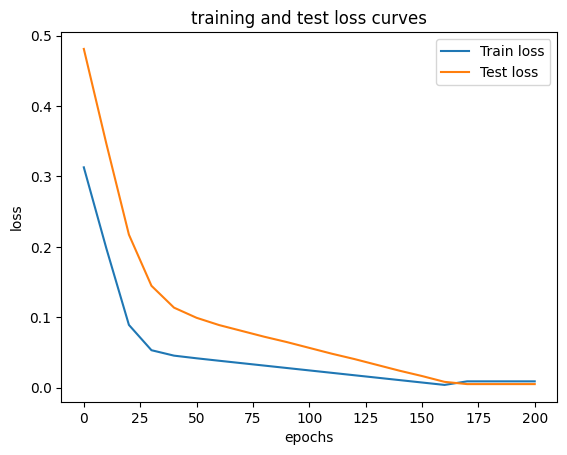

In [293]:
#plot the loss curves
#before do so change it to numpy

import numpy as np

plt.plot(epoch_count,np.array(torch.tensor(loss_valves)), label="Train loss")
plt.plot(epoch_count,np.array(torch.tensor(test_loss_valves)), label="Test loss")
plt.title("training and test loss curves")
plt.ylabel("loss")
plt.xlabel("epochs")
plt.legend()


In [289]:
#以下来对比一下训练的成果
with torch.inference_mode():
    Y_preds_new = model_0(X_test)
    

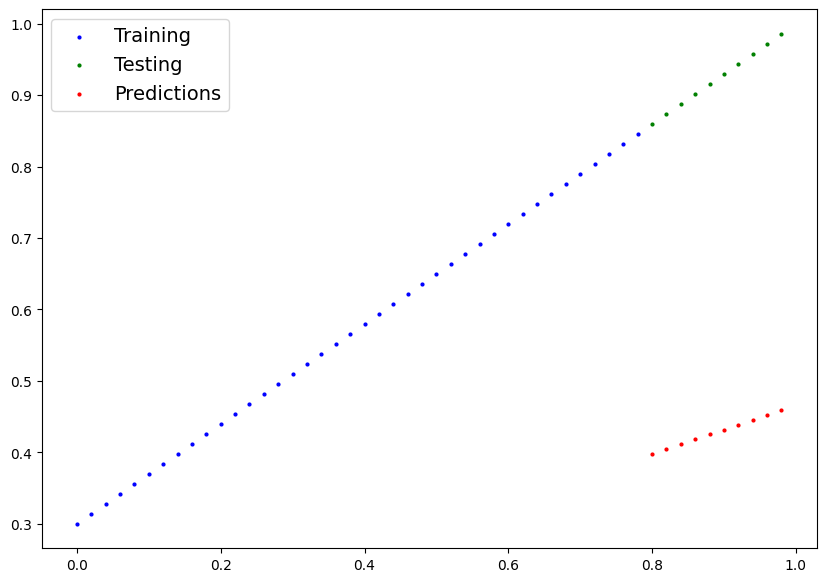

In [290]:
plot_predictions(predictions=Y_preds)

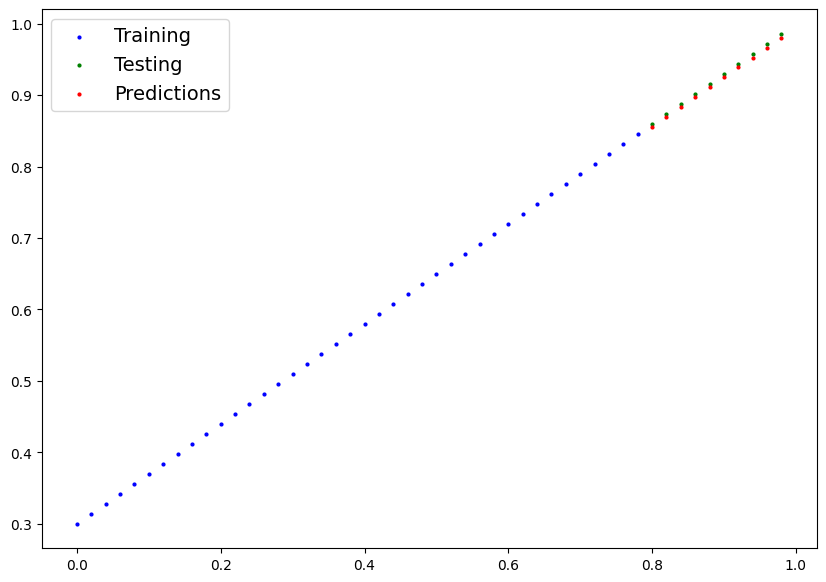

In [291]:
plot_predictions(predictions=Y_preds_new)

## saving a model in pytorch

3 ways to know for saving and loading models in PyTorch

1. `torch.save()` - save a pytorch object in python a pickle format
2. `torch.load()` - load a saved pytorch project
3. `torch.nn.Module.load_state_dict()` - load a model's saved state dictionary

In [295]:
model_0.state_dict()

OrderedDict([('weights', tensor([0.6951])), ('bias', tensor([0.2993]))])

In [298]:
#问题：这整个过程都在干什么？只把训练好的参数存下来吗，看起来像这样。
#saving model
from pathlib import Path

#1.create model directory
MODEL_PATH = Path("models")
MODEL_PATH.mkdir(parents=True,exist_ok=True)

#2. create model save Path
MODEL_NAME = "B_Pytorch_workflow.pth"
MODEL_SAVE_PATH = MODEL_PATH / MODEL_NAME

MODEL_SAVE_PATH

#3.save the model state_dict
print(f"saving model to:{MODEL_SAVE_PATH}")
torch.save(obj=model_0.state_dict(),
           f=MODEL_SAVE_PATH)

saving model to:models\B_Pytorch_workflow.pth


## loading a model

In [299]:
# To load in we have to instatiate a new instance of our new model class
loaded_model_0 = LinearRegressionModel()
# load the saved state_dict of model(this will uupdate the new instance with updated parameters)
loaded_model_0.load_state_dict(torch.load(f=MODEL_SAVE_PATH))


<All keys matched successfully>

In [300]:
loaded_model_0.state_dict()

OrderedDict([('weights', tensor([0.6951])), ('bias', tensor([0.2993]))])

In [ ]:
#make predictions to make sure loaded successfully

#first we make some preds
model_0.eval()
with torch.inference_mode():
    Y_preds = model_0(X_test)


#then we check
loaded_model_0.eval()
with torch.inference_mode():
    loaded_model_preds = loaded_model_0(X_test)

loaded_model_preds,Y_preds == loaded_model_preds

(tensor([[0.8554],
         [0.8693],
         [0.8832],
         [0.8971],
         [0.9110],
         [0.9249],
         [0.9388],
         [0.9527],
         [0.9666],
         [0.9805]]),
 tensor([[True],
         [True],
         [True],
         [True],
         [True],
         [True],
         [True],
         [True],
         [True],
         [True]]))

## 6.putting all together

back all through the steps

have a look is ok   
it's just a refresh in the tutorial    
from 7:44 to 8:32    

to look extra content go to website